Harivdan Shrihari Narayanshastri

In [24]:
# ========================================
# STUDENT PERFORMANCE PREDICTION - FA2
# ========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Load the data (separator is semicolon)
df = pd.read_csv('sample_data/student-mat.csv', sep=';')

# Basic exploration
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Dataset Shape: (395, 33)
Rows: 395, Columns: 33

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Column 

In [26]:
print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)
print("\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")

# Display G3 statistics (final grade)
print("\nG3 (Final Grade) Statistics:")
print(df['G3'].describe())
print(f"\nGrade Distribution:")
print(df['G3'].value_counts().sort_index())


DATA QUALITY ASSESSMENT

Missing values:
0 total missing values

G3 (Final Grade) Statistics:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Grade Distribution:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


In [27]:
print("\n" + "="*60)
print("TARGET VARIABLE CREATION")
print("="*60)

# Create Target Variable: Pass (G3 >= 10) vs Fail (G3 < 10)
# Based on Portuguese/European grading system
df['target'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

print("\nTarget distribution:")
target_counts = df['target'].value_counts()
print(target_counts)
print(f"\nClass Distribution:")
for i, count in target_counts.items():
    label = 'PASS' if i == 1 else 'FAIL'
    percentage = (count / len(df)) * 100
    print(f"  {label}: {count} students ({percentage:.2f}%)")

pass_rate = df['target'].mean() * 100
print(f"\nPass Rate: {pass_rate:.2f}%")

# Drop G1, G2, G3 to avoid data leakage
# G1 & G2 are prior grades, G3 is target
df_model = df.drop(['G3', 'G1', 'G2'], axis=1)

# Identify categorical and numerical columns
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('target')

print(f"\nFeature Types:")
print(f"  Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"  Numerical features ({len(numerical_cols)}): {numerical_cols}")


TARGET VARIABLE CREATION

Target distribution:
target
1    265
0    130
Name: count, dtype: int64

Class Distribution:
  PASS: 265 students (67.09%)
  FAIL: 130 students (32.91%)

Pass Rate: 67.09%

Feature Types:
  Categorical features (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
  Numerical features (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [28]:
print("\n" + "="*60)
print("ENCODING CATEGORICAL FEATURES")
print("="*60)

# Prepare features and target
X = df_model.drop('target', axis=1).copy()
y = df_model['target'].copy()

# Encode categorical variables using LabelEncoder
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le
    print(f"  OK Encoded '{col}' ({len(le.classes_)} unique values)")

print("\nEncoded data sample:")
print(X.head())


ENCODING CATEGORICAL FEATURES
  OK Encoded 'school' (2 unique values)
  OK Encoded 'sex' (2 unique values)
  OK Encoded 'address' (2 unique values)
  OK Encoded 'famsize' (2 unique values)
  OK Encoded 'Pstatus' (2 unique values)
  OK Encoded 'Mjob' (5 unique values)
  OK Encoded 'Fjob' (5 unique values)
  OK Encoded 'reason' (4 unique values)
  OK Encoded 'guardian' (3 unique values)
  OK Encoded 'schoolsup' (2 unique values)
  OK Encoded 'famsup' (2 unique values)
  OK Encoded 'paid' (2 unique values)
  OK Encoded 'activities' (2 unique values)
  OK Encoded 'nursery' (2 unique values)
  OK Encoded 'higher' (2 unique values)
  OK Encoded 'internet' (2 unique values)
  OK Encoded 'romantic' (2 unique values)

Encoded data sample:
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15   

In [29]:
print("\n" + "="*60)
print("DATA SPLITTING & SCALING")
print("="*60)

# Split data: 80% train, 20% test (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTrain set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

# Scale the features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling complete!")
print(f"  Train data mean: {X_train_scaled.mean():.4f}")
print(f"  Train data std: {X_train_scaled.std():.4f}")


DATA SPLITTING & SCALING

Training set size: 316
Test set size: 79

Train set class distribution:
target
1    212
0    104
Name: count, dtype: int64

Test set class distribution:
target
1    53
0    26
Name: count, dtype: int64

Feature scaling complete!
  Train data mean: 0.0000
  Train data std: 1.0000


In [30]:
print("\n" + "="*60)
print("TRAINING BASELINE MODELS")
print("="*60)

# Dictionary to store models and results
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42,
                                           max_depth=15, n_jobs=-1)
}

predictions = {}
probabilities = {}
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Use scaled data for Logistic Regression, original for tree-based models
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Store predictions and probabilities
    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"\nOK {name} Results:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))


TRAINING BASELINE MODELS

Training Logistic Regression...

OK Logistic Regression Results:
  Accuracy:  0.6835
  Precision: 0.7258
  Recall:    0.8491
  F1-Score:  0.7826
  ROC-AUC:   0.5900

Classification Report:
              precision    recall  f1-score   support

        Fail       0.53      0.35      0.42        26
        Pass       0.73      0.85      0.78        53

    accuracy                           0.68        79
   macro avg       0.63      0.60      0.60        79
weighted avg       0.66      0.68      0.66        79


Training Decision Tree...

OK Decision Tree Results:
  Accuracy:  0.6329
  Precision: 0.7069
  Recall:    0.7736
  F1-Score:  0.7387
  ROC-AUC:   0.5577

Classification Report:
              precision    recall  f1-score   support

        Fail       0.43      0.35      0.38        26
        Pass       0.71      0.77      0.74        53

    accuracy                           0.63        79
   macro avg       0.57      0.56      0.56        79
weighte

In [31]:
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("="*60)

results_df = pd.DataFrame(results).T
print(results_df.round(4))
print("="*60)

# Identify best model by each metric
print("\nOK Best Models by Metric:")
for metric in results_df.columns:
    best = results_df[metric].idxmax()
    score = results_df[metric].max()
    print(f"  {metric}: {best} ({score:.4f})")

best_model_name = results_df['F1-Score'].idxmax()
print(f"\nBEST OVERALL MODEL: {best_model_name}")


MODEL PERFORMANCE COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6835     0.7258  0.8491    0.7826   0.5900
Decision Tree          0.6329     0.7069  0.7736    0.7387   0.5577
Random Forest          0.6709     0.7077  0.8679    0.7797   0.6524

OK Best Models by Metric:
  Accuracy: Logistic Regression (0.6835)
  Precision: Logistic Regression (0.7258)
  Recall: Random Forest (0.8679)
  F1-Score: Logistic Regression (0.7826)
  ROC-AUC: Random Forest (0.6524)

BEST OVERALL MODEL: Logistic Regression



GENERATING VISUALIZATIONS

OK Saved: model_comparison.png


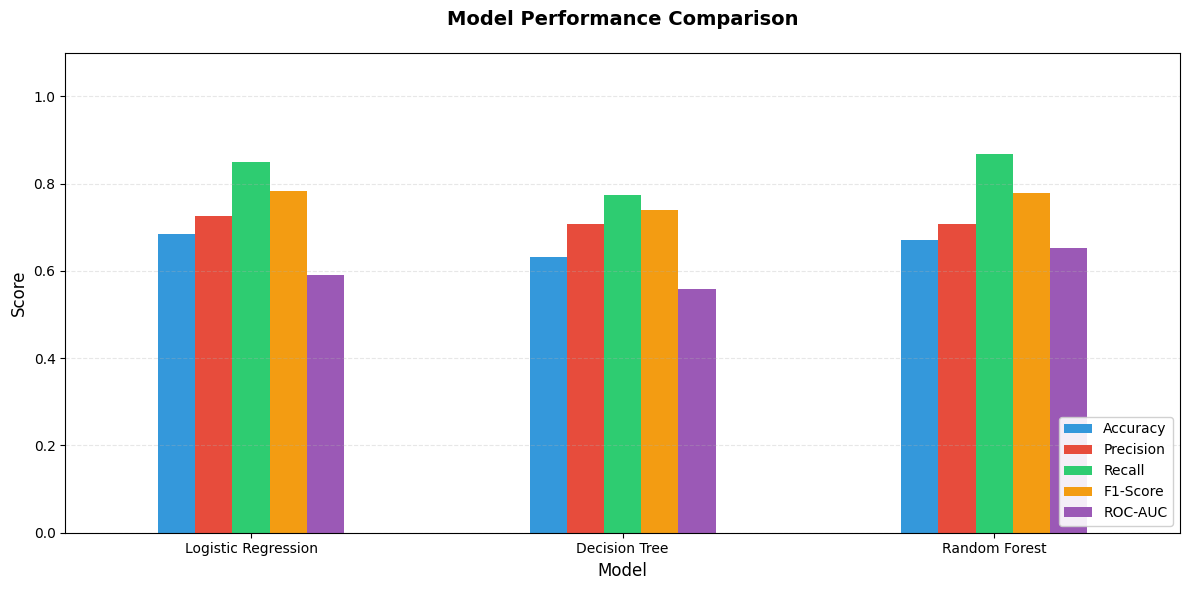

In [32]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Bar chart comparing all models
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\nOK Saved: model_comparison.png")
plt.show()

OK Saved: confusion_matrices.png


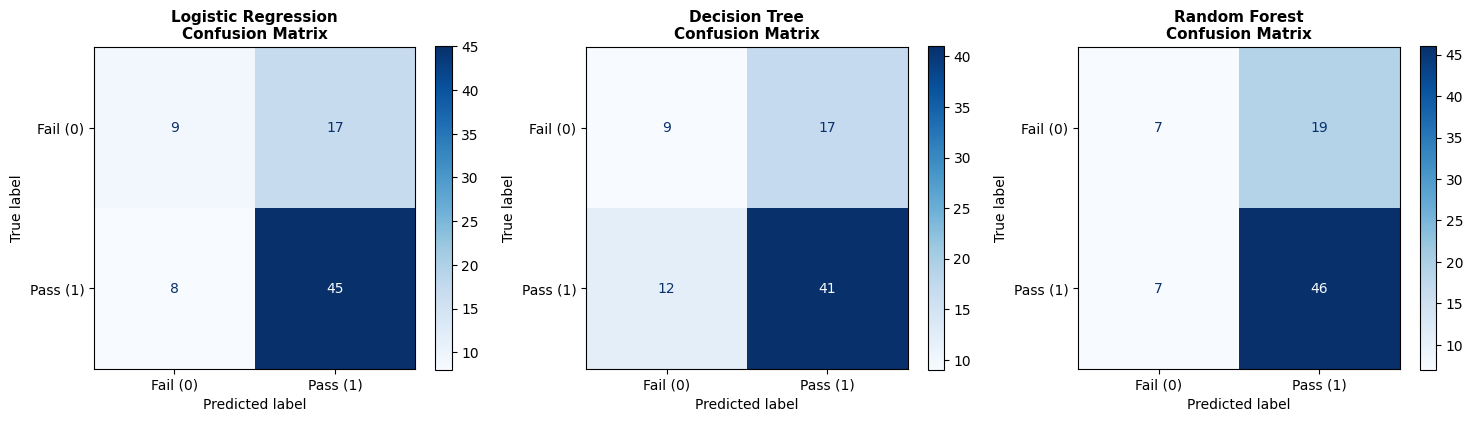

In [33]:
# Confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    # Get predictions
    y_pred_cm = predictions[name]

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_cm, ax=axes[idx], cmap='Blues',
        display_labels=['Fail (0)', 'Pass (1)'], values_format='d'
    )
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("OK Saved: confusion_matrices.png")
plt.show()

OK Saved: roc_curves.png


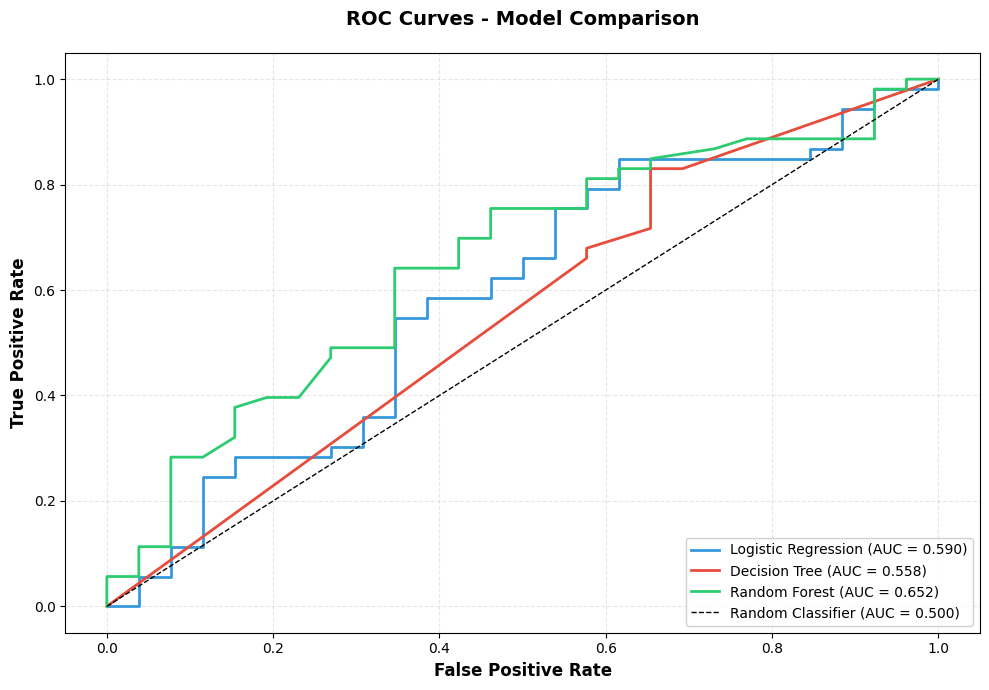

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for idx, (name, y_prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})',
            linewidth=2, color=colors[idx])

# Plot random classifier line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print("OK Saved: roc_curves.png")
plt.show()


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
  Feature  Importance
 absences    0.107071
 failures    0.105106
    goout    0.056118
      age    0.053040
   health    0.046239
     Mjob    0.045408
     Medu    0.041970
 freetime    0.040584
     Fedu    0.039116
     Walc    0.036751
   famrel    0.036575
     Fjob    0.036326
studytime    0.034166
   reason    0.031489
 guardian    0.026999

OK Saved: feature_importance.png


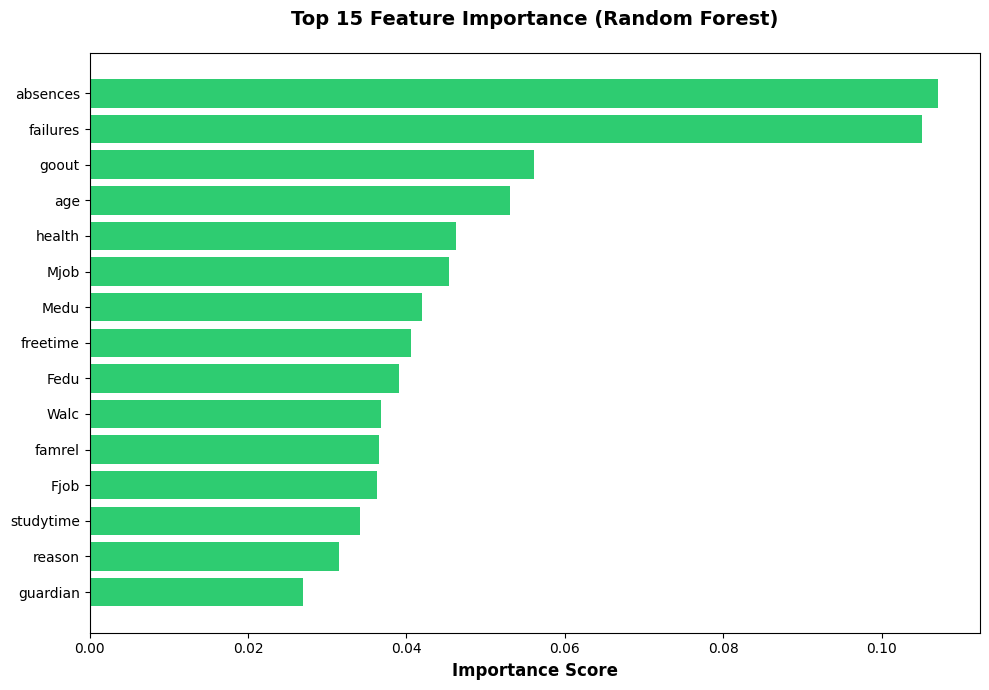

In [35]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 7))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['Importance'], color='#2ecc71')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nOK Saved: feature_importance.png")
plt.show()

In [36]:
print("\n" + "="*60)
print("CROSS-VALIDATION ANALYSIS (5-FOLD)")
print("="*60)

cv_results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                   cv=5, scoring='f1', n_jobs=-1)
    else:
        cv_scores = cross_val_score(model, X_train, y_train,
                                   cv=5, scoring='f1', n_jobs=-1)

    cv_results[name] = cv_scores
    print(f"\n{name}:")
    print(f"  CV Scores: {[f'{score:.4f}' for score in cv_scores]}")
    print(f"  Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CROSS-VALIDATION ANALYSIS (5-FOLD)

Logistic Regression:
  CV Scores: ['0.7660', '0.7209', '0.7835', '0.7865', '0.8222']
  Mean F1: 0.7758 (+/- 0.0330)

Decision Tree:
  CV Scores: ['0.6914', '0.7250', '0.7907', '0.7209', '0.7059']
  Mean F1: 0.7268 (+/- 0.0341)

Random Forest:
  CV Scores: ['0.8125', '0.7742', '0.8163', '0.8247', '0.8454']
  Mean F1: 0.8146 (+/- 0.0232)


In [37]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\nTesting parameter combinations...")
print("This may take 1-2 minutes...\n")

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nOK Best Parameters: {grid_search.best_params_}")
print(f"  Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

best_results = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1-Score': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best)
}

print(f"\nBest Model Test Performance:")
for metric, score in best_results.items():
    print(f"  {metric}: {score:.4f}")



HYPERPARAMETER TUNING - RANDOM FOREST

Testing parameter combinations...
This may take 1-2 minutes...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

OK Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV F1-Score: 0.8366

Best Model Test Performance:
  Accuracy: 0.6329
  Precision: 0.6765
  Recall: 0.8679
  F1-Score: 0.7603
  ROC-AUC: 0.6444


In [38]:
print("\n" + "="*60)
print("TUNING RESULTS - BASELINE vs OPTIMIZED")
print("="*60)

baseline_rf = results['Random Forest']
comparison_df = pd.DataFrame({
    'Baseline RF': baseline_rf,
    'Tuned RF': best_results
})

print(comparison_df.round(4))

print("\n" + "-"*60)
for metric in comparison_df.index:
    baseline = baseline_rf[metric]
    tuned = best_results[metric]
    improvement = tuned - baseline
    pct_change = (improvement / baseline) * 100
    arrow = "UP" if improvement > 0 else "DOWN"
    print(f"{metric:12} | Baseline: {baseline:.4f} -> Tuned: {tuned:.4f} {arrow} ({pct_change:+.2f}%)")


TUNING RESULTS - BASELINE vs OPTIMIZED
           Baseline RF  Tuned RF
Accuracy        0.6709    0.6329
Precision       0.7077    0.6765
Recall          0.8679    0.8679
F1-Score        0.7797    0.7603
ROC-AUC         0.6524    0.6444

------------------------------------------------------------
Accuracy     | Baseline: 0.6709 -> Tuned: 0.6329 DOWN (-5.66%)
Precision    | Baseline: 0.7077 -> Tuned: 0.6765 DOWN (-4.41%)
Recall       | Baseline: 0.8679 -> Tuned: 0.8679 DOWN (+0.00%)
F1-Score     | Baseline: 0.7797 -> Tuned: 0.7603 DOWN (-2.48%)
ROC-AUC      | Baseline: 0.6524 -> Tuned: 0.6444 DOWN (-1.22%)



FEATURE CORRELATION WITH TARGET

Top 10 positively correlated features:
higher       0.157708
Medu         0.115396
Fedu         0.108057
reason       0.099300
paid         0.092665
studytime    0.074613
sex          0.070618
internet     0.061791
address      0.052282
famrel       0.046683
Name: target, dtype: float64

Top 10 negatively correlated features:
Dalc        -0.057343
famsup      -0.059219
health      -0.065668
absences    -0.092244
romantic    -0.097737
schoolsup   -0.099860
guardian    -0.101407
age         -0.179645
goout       -0.183399
failures    -0.337731
Name: target, dtype: float64

OK Saved: feature_correlation.png


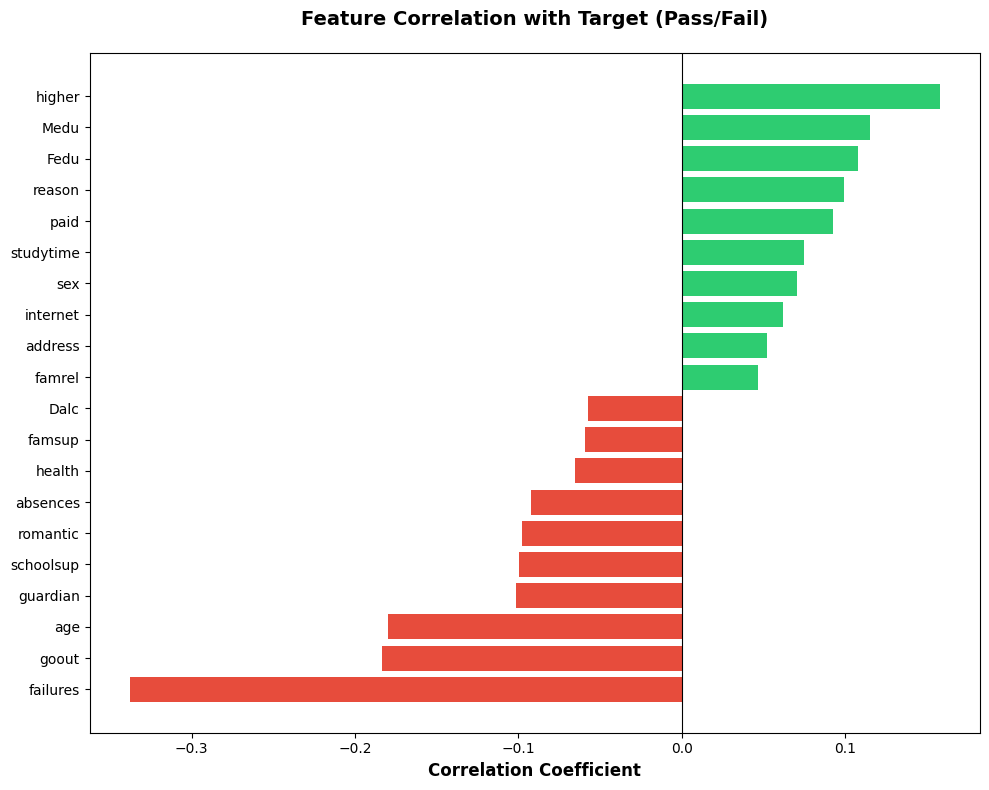

In [39]:
print("\n" + "="*60)
print("FEATURE CORRELATION WITH TARGET")
print("="*60)

correlations = X.copy()
correlations['target'] = y
corr_with_target = correlations.corr()['target'].drop('target').sort_values(ascending=False)

print("\nTop 10 positively correlated features:")
print(corr_with_target.head(10))
print("\nTop 10 negatively correlated features:")
print(corr_with_target.tail(10))

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
top_corr_features = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])
top_corr_features = top_corr_features.sort_values()
colors_hm = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_corr_features]
ax.barh(range(len(top_corr_features)), top_corr_features.values, color=colors_hm)
ax.set_yticks(range(len(top_corr_features)))
ax.set_yticklabels(top_corr_features.index)
ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Feature Correlation with Target (Pass/Fail)', fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
print("\nOK Saved: feature_correlation.png")
plt.show()

In [40]:
print("\n" + "="*60)
print("EXAMPLE PREDICTIONS ON NEW DATA")
print("="*60)

# Select 5 random students from test set
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_students = X_test.iloc[sample_indices]
sample_actual = y_test.iloc[sample_indices]

print("\nPredicting for 5 random test students:\n")

for i, idx in enumerate(sample_indices):
    student = sample_students.iloc[i:i+1]
    actual = sample_actual.iloc[i]

    # Use best tuned model (Random Forest)
    pred = best_model.predict(student)[0]
    prob = best_model.predict_proba(student)[0]

    actual_label = "PASS" if actual == 1 else "FAIL"
    pred_label = "PASS" if pred == 1 else "FAIL"
    confidence = prob[int(pred)]

    status = "CORRECT" if actual == pred else "WRONG"

    print(f"Student {i+1}:")
    print(f"  Actual:     {actual_label}")
    print(f"  Predicted:  {pred_label} (Confidence: {confidence:.2%})")
    print(f"  Status:     {status}")
    print()


EXAMPLE PREDICTIONS ON NEW DATA

Predicting for 5 random test students:

Student 1:
  Actual:     FAIL
  Predicted:  PASS (Confidence: 88.75%)
  Status:     WRONG

Student 2:
  Actual:     PASS
  Predicted:  PASS (Confidence: 76.53%)
  Status:     CORRECT

Student 3:
  Actual:     FAIL
  Predicted:  PASS (Confidence: 56.66%)
  Status:     WRONG

Student 4:
  Actual:     PASS
  Predicted:  PASS (Confidence: 88.74%)
  Status:     CORRECT

Student 5:
  Actual:     PASS
  Predicted:  FAIL (Confidence: 50.26%)
  Status:     WRONG



In [41]:
print("\n" + "="*60)
print("SAVING FINAL MODEL")
print("="*60)

# Save best model
model_data = {
    'model': best_model,
    'scaler': scaler,
    'encoder_dict': le_dict,
    'feature_names': X.columns.tolist(),
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols,
    'results': best_results
}

with open('student_performance_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\nOK Model saved as 'student_performance_model.pkl'")
print(f"OK Best Model: {best_model.__class__.__name__}")
print(f"OK Test F1-Score: {best_results['F1-Score']:.4f}")


SAVING FINAL MODEL

OK Model saved as 'student_performance_model.pkl'
OK Best Model: RandomForestClassifier
OK Test F1-Score: 0.7603


In [42]:
print("\n" + "="*70)
print("FINAL SUMMARY - STUDENT PERFORMANCE PREDICTION PROJECT")
print("="*70)

print(f"""
DATASET:
   - Total Students: {len(df)}
   - Features: {len(X.columns)}
   - Target: Pass (G3 >= 10) / Fail (G3 < 10)
   - Pass Rate: {pass_rate:.2f}%

DATA PREPROCESSING:
   - Categorical Features: {len(categorical_cols)} (Label Encoded)
   - Numerical Features: {len(numerical_cols)}
   - Train Set: {len(X_train)} students
   - Test Set: {len(X_test)} students

MODELS TRAINED:
   1. Logistic Regression
   2. Decision Tree (max_depth=10)
   3. Random Forest (n_estimators=100)

BASELINE BEST MODEL: {best_model_name.upper()}
   - Accuracy:  {baseline_rf['Accuracy']:.4f}
   - Precision: {baseline_rf['Precision']:.4f}
   - Recall:    {baseline_rf['Recall']:.4f}
   - F1-Score:  {baseline_rf['F1-Score']:.4f}
   - ROC-AUC:   {baseline_rf['ROC-AUC']:.4f}

TUNED MODEL (Random Forest):
   - F1-Score: {best_results['F1-Score']:.4f}
   - Improvement: {((best_results['F1-Score'] - baseline_rf['F1-Score']) / baseline_rf['F1-Score'] * 100):+.2f}%

""")



FINAL SUMMARY - STUDENT PERFORMANCE PREDICTION PROJECT

DATASET:
   - Total Students: 395
   - Features: 30
   - Target: Pass (G3 >= 10) / Fail (G3 < 10)
   - Pass Rate: 67.09%

DATA PREPROCESSING:
   - Categorical Features: 17 (Label Encoded)
   - Numerical Features: 13
   - Train Set: 316 students
   - Test Set: 79 students

MODELS TRAINED:
   1. Logistic Regression
   2. Decision Tree (max_depth=10)
   3. Random Forest (n_estimators=100)

BASELINE BEST MODEL: LOGISTIC REGRESSION
   - Accuracy:  0.6709
   - Precision: 0.7077
   - Recall:    0.8679
   - F1-Score:  0.7797
   - ROC-AUC:   0.6524

TUNED MODEL (Random Forest):
   - F1-Score: 0.7603
   - Improvement: -2.48%


